# Loan Approval Prediction

**Context:** a lender wants to decide automatically which loan applications to approve. The goal is a model that predicts approval from information available when the application is made, and an explanation of what drives the decision.

**Data:** [Financial Risk for Loan Approval](https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval) on Kaggle. It is a synthetic dataset of 20,000 applications with 36 columns: applicant profile, credit history, assets and debts, loan terms, and two targets (`LoanApproved` and `RiskScore`).

**Questions**

1. What separates approved from rejected applications?
2. Which columns can be used without leaking the answer?
3. How well can approval be predicted, and which model works best?
4. Which threshold should be used to approve a loan?

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, classification_report,
    precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4.5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 2. Load and check the data

In [2]:
df = pd.read_csv("data/loan.csv", parse_dates=["ApplicationDate"])
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

20,000 rows x 36 columns


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicated rows:", df.duplicated().sum())
print("Negative values in numeric columns:", (df.select_dtypes("number") < 0).sum().sum())
print(f"Approval rate: {df['LoanApproved'].mean():.1%}")

Missing values: 0
Duplicated rows: 0
Negative values in numeric columns: 0
Approval rate: 23.9%


The data has no missing values or duplicates. About 1 in 4 applications is approved, so the classes are imbalanced but not extremely.

### 2.1 Application date

In [4]:
dates = df["ApplicationDate"]
print("First date:", dates.min().date(), " Last date:", dates.max().date())
print("Days between consecutive applications:", dates.diff().dt.days.value_counts().to_dict())

First date: 2018-01-01  Last date: 2072-10-03
Days between consecutive applications: {1.0: 19999}


There is exactly one application per day, from 2018 to 2072. The date is just a row counter created by the data generator, so features built from it (year, month, weekday) carry no information about the applicant. The column is dropped.

### 2.2 Consistency between related columns

In [5]:
monthly_mismatch = (df["AnnualIncome"] / 12 - df["MonthlyIncome"]).abs() > 1
networth_mismatch = df["TotalAssets"] - df["TotalLiabilities"] != df["NetWorth"]

print(f"MonthlyIncome != AnnualIncome / 12: {monthly_mismatch.sum():,} rows")
print(f"NetWorth != TotalAssets - TotalLiabilities: {networth_mismatch.sum():,} rows")
print("Rows with NetWorth mismatch where liabilities exceed assets:",
      (networth_mismatch & (df["TotalLiabilities"] > df["TotalAssets"])).sum())

MonthlyIncome != AnnualIncome / 12: 195 rows
NetWorth != TotalAssets - TotalLiabilities: 4,801 rows
Rows with NetWorth mismatch where liabilities exceed assets: 4629


Two inconsistencies come from the synthetic generator:

- In 195 rows, monthly income is only 50% to 67% of annual income / 12.
- Net worth is always positive, even when liabilities are larger than assets (4,801 rows).

They are kept as they are, since there is no way to know which value is correct, but they are a reminder that this data is simulated.

## 3. What separates approved from rejected applications?

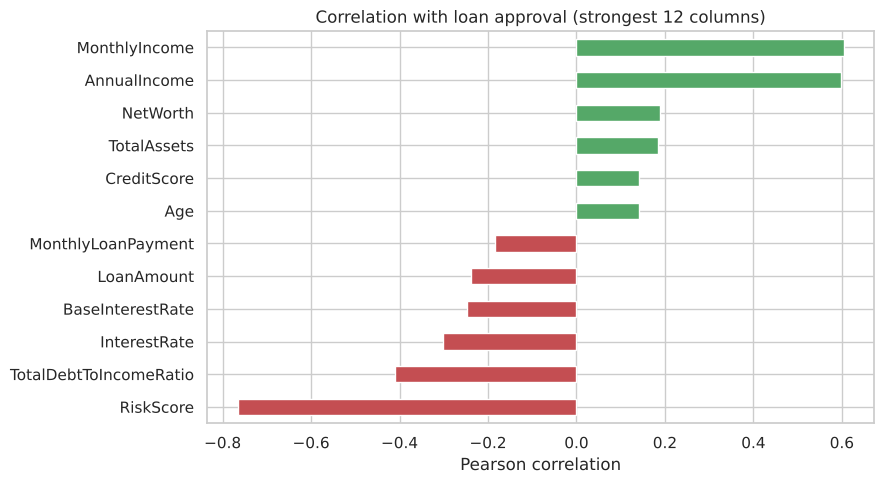

In [6]:
numeric = df.select_dtypes("number").drop(columns=["LoanApproved"])
corr = numeric.corrwith(df["LoanApproved"]).sort_values()

top = pd.concat([corr.head(6), corr.tail(6)])
ax = top.plot.barh(color=["C3" if v < 0 else "C2" for v in top], figsize=(9, 5))
ax.set(title="Correlation with loan approval (strongest 12 columns)", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()

`RiskScore` has by far the strongest relationship with approval. Among the applicant's own information, income has the strongest positive effect and the total debt-to-income ratio the strongest negative effect.

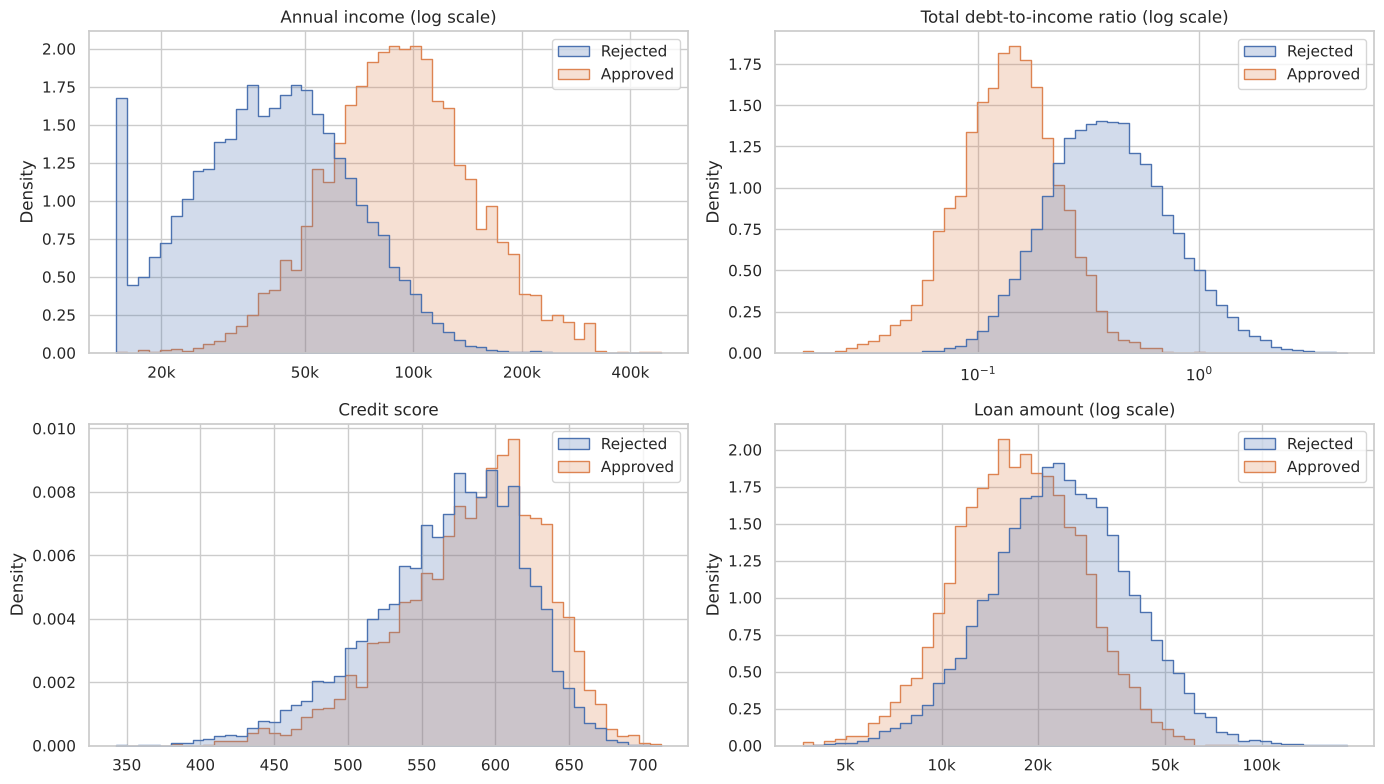

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
labels = df["LoanApproved"].map({0: "Rejected", 1: "Approved"})
plots = [
    ("AnnualIncome", True, "Annual income (log scale)"),
    ("TotalDebtToIncomeRatio", True, "Total debt-to-income ratio (log scale)"),
    ("CreditScore", False, "Credit score"),
    ("LoanAmount", True, "Loan amount (log scale)"),
]
for ax, (col, log, title) in zip(axes.flat, plots):
    sns.histplot(data=df, x=col, hue=labels, hue_order=["Rejected", "Approved"],
                 log_scale=log, bins=50, stat="density", common_norm=False,
                 element="step", ax=ax)
    ax.set(title=title, xlabel="")
    ax.get_legend().set_title("")
    ticks = {"AnnualIncome": [20e3, 50e3, 100e3, 200e3, 400e3],
             "LoanAmount": [5e3, 10e3, 20e3, 50e3, 100e3]}.get(col)
    if ticks:
        ax.set_xticks(ticks, [f"{t/1000:,.0f}k" for t in ticks])
        ax.xaxis.set_minor_formatter(lambda v, _: "")
plt.tight_layout()
plt.show()

Approved applicants have higher incomes and much lower debt-to-income ratios. Credit score helps, but the two groups overlap a lot. Larger loans are approved less often. The peak at the left of the income chart is the minimum income in the data (15,000), where the generator seems to have clipped lower values.

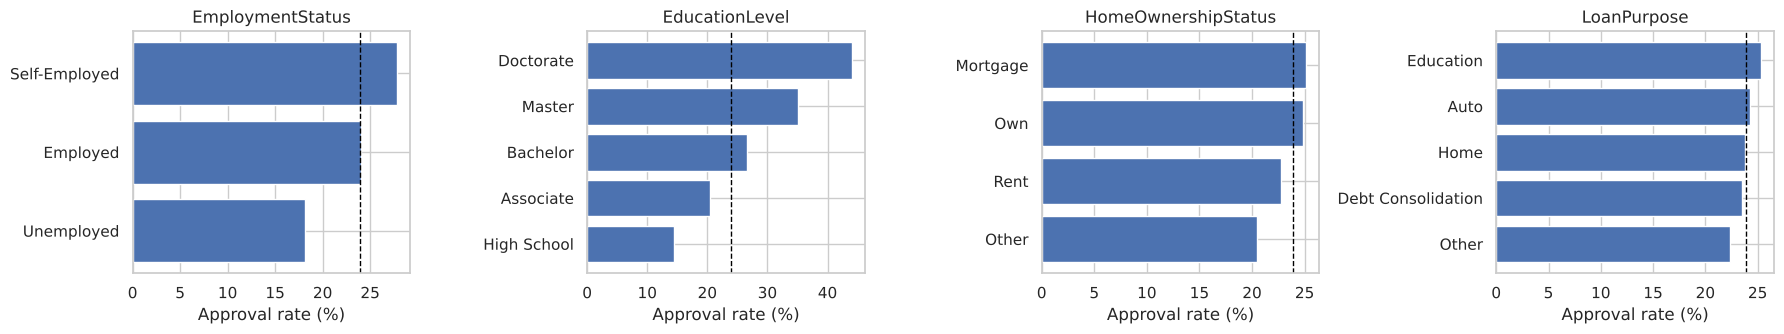

In [8]:
cat_cols = ["EmploymentStatus", "EducationLevel", "HomeOwnershipStatus", "LoanPurpose"]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)["LoanApproved"].mean().sort_values()
    ax.barh(rate.index, rate.values * 100, color="C0")
    ax.axvline(df["LoanApproved"].mean() * 100, color="black", ls="--", lw=1)
    ax.set(title=col, xlabel="Approval rate (%)")
plt.tight_layout()
plt.show()

Education has a strong effect: 44% of applicants with a doctorate are approved, against 14% with only high school. Employment status matters less (the unemployed are approved less often), and home ownership and loan purpose make almost no difference. The dashed line is the overall approval rate.

## 4. Which columns can be used?

A model should only use information known before the lender makes the decision. Three groups of columns need a closer look.

### 4.1 RiskScore

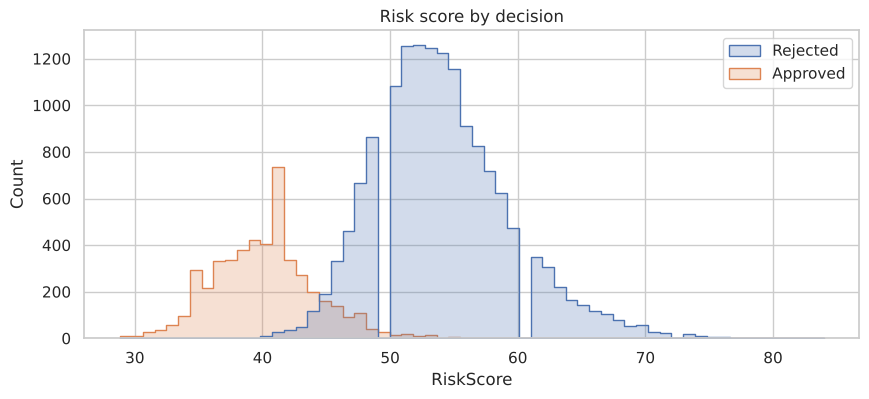

Approve if RiskScore < 44: matches the real decision in 95.3% of cases
Approve if RiskScore < 45: matches the real decision in 96.5% of cases
Approve if RiskScore < 46: matches the real decision in 96.3% of cases


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=df, x="RiskScore", hue=labels, hue_order=["Rejected", "Approved"],
             bins=60, element="step", ax=ax)
ax.set(title="Risk score by decision")
ax.get_legend().set_title("")
plt.show()

for cut in [44, 45, 46]:
    acc = ((df["RiskScore"] < cut) == df["LoanApproved"]).mean()
    print(f"Approve if RiskScore < {cut}: matches the real decision in {acc:.1%} of cases")

A single rule, *approve if RiskScore < 45*, reproduces 96.5% of the decisions. The risk score is the lender's own assessment and is in practice a second version of the target. It is excluded.

### 4.2 Interest rates and loan payment

In [10]:
X_rate = df[["CreditScore", "LoanDuration", "LoanAmount"]]
r2 = LinearRegression().fit(X_rate, df["BaseInterestRate"]).score(X_rate, df["BaseInterestRate"])
print(f"R² of BaseInterestRate ~ CreditScore + LoanDuration + LoanAmount: {r2:.4f}")

r = df["InterestRate"] / 12
n_months = df["LoanDuration"]
payment = df["LoanAmount"] * r / (1 - (1 + r) ** -n_months)
print(f"Max difference between MonthlyLoanPayment and the annuity formula: {(payment - df['MonthlyLoanPayment']).abs().max():.2e}")

total_dti = (df["MonthlyDebtPayments"] + df["MonthlyLoanPayment"]) / df["MonthlyIncome"]
print(f"Max difference for TotalDebtToIncomeRatio: {(total_dti - df['TotalDebtToIncomeRatio']).abs().max():.2e}")

R² of BaseInterestRate ~ CreditScore + LoanDuration + LoanAmount: 1.0000
Max difference between MonthlyLoanPayment and the annuity formula: 5.82e-11
Max difference for TotalDebtToIncomeRatio: 8.88e-16


- `BaseInterestRate` is an exact linear function of credit score, loan duration and loan amount, so it adds no new information but is harmless.
- `InterestRate` is the rate the lender actually offers, which is set as part of the decision. It is excluded.
- `MonthlyLoanPayment` is computed exactly from `InterestRate` with the annuity formula, and `TotalDebtToIncomeRatio` is computed from that payment. Dropping only `InterestRate` does not remove it: the model can recover it from these two columns.

To be safe, two feature sets are compared in section 6:

- **All features:** everything except `RiskScore`, `InterestRate` and the date.
- **Applicant only:** also removes `MonthlyLoanPayment` and `TotalDebtToIncomeRatio`, so no information from the offered rate is used.

## 5. Train / test split

In [11]:
TARGET = "LoanApproved"
drop_always = ["ApplicationDate", "RiskScore", "InterestRate"]
rate_derived = ["MonthlyLoanPayment", "TotalDebtToIncomeRatio"]

X = df.drop(columns=[TARGET] + drop_always)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows  Test: {len(X_test):,} rows  "
      f"Approval rate train/test: {y_train.mean():.1%} / {y_test.mean():.1%}")

Train: 14,000 rows  Test: 6,000 rows  Approval rate train/test: 23.9% / 23.9%


## 6. Models

Three models are compared with 5-fold cross-validation on the training set:

- **Logistic Regression**, a transparent baseline, with standardised numeric features and class weights to balance approvals and rejections.
- **XGBoost** and **LightGBM**, gradient-boosted trees that can capture non-linear effects and interactions.

Categorical columns are one-hot encoded inside the pipeline, so nothing from the test set is used during training.

In [12]:
def make_preprocessor(columns, scale):
    cat = [c for c in columns if X[c].dtype == object or str(X[c].dtype) in ("str", "string", "category")]
    num = [c for c in columns if c not in cat]
    num_step = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([
        ("num", num_step, num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])

def make_models(columns):
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    return {
        "Logistic Regression": Pipeline([
            ("prep", make_preprocessor(columns, scale=True)),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
        ]),
        "XGBoost": Pipeline([
            ("prep", make_preprocessor(columns, scale=False)),
            ("clf", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
                                  subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "LightGBM": Pipeline([
            ("prep", make_preprocessor(columns, scale=False)),
            ("clf", LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                   class_weight="balanced", random_state=RANDOM_STATE, verbose=-1)),
        ]),
    }

feature_sets = {
    "All features": list(X.columns),
    "Applicant only": [c for c in X.columns if c not in rate_derived],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for set_name, cols in feature_sets.items():
    for model_name, model in make_models(cols).items():
        scores = cross_val_score(model, X_train[cols], y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
        rows.append({"features": set_name, "model": model_name,
                     "cv_roc_auc_mean": scores.mean(), "cv_roc_auc_std": scores.std()})

cv_results = pd.DataFrame(rows).pivot(index="model", columns="features", values="cv_roc_auc_mean")
cv_results.round(4)

features,All features,Applicant only
model,,
LightGBM,0.9776,0.9741
Logistic Regression,0.9803,0.9754
XGBoost,0.9786,0.9753


In [13]:
best_auc = cv_results.stack().max()
loss = cv_results["All features"] - cv_results["Applicant only"]
print("Drop in ROC AUC when rate-derived columns are removed:")
print(loss.round(4).to_string())

Drop in ROC AUC when rate-derived columns are removed:
model
LightGBM               0.0035
Logistic Regression    0.0049
XGBoost                0.0034


All three models reach a cross-validated ROC AUC between 0.97 and 0.98. Removing the columns derived from the offered interest rate lowers it by less than 0.005, so the models do not depend on them. The rest of the notebook uses the **applicant only** feature set, which is the safer choice for a real lending decision.

## 7. Test set evaluation

In [14]:
cols = feature_sets["Applicant only"]
models = make_models(cols)
probas = {}
for name, model in models.items():
    model.fit(X_train[cols], y_train)
    probas[name] = model.predict_proba(X_test[cols])[:, 1]

summary = pd.DataFrame({
    name: {"ROC AUC": roc_auc_score(y_test, p), "PR AUC": average_precision_score(y_test, p)}
    for name, p in probas.items()
}).T.sort_values("ROC AUC", ascending=False)
summary.round(4)

,ROC AUC,PR AUC
XGBoost,0.9730,0.9271
Logistic Regression,0.9721,0.9246
LightGBM,0.9715,0.9241


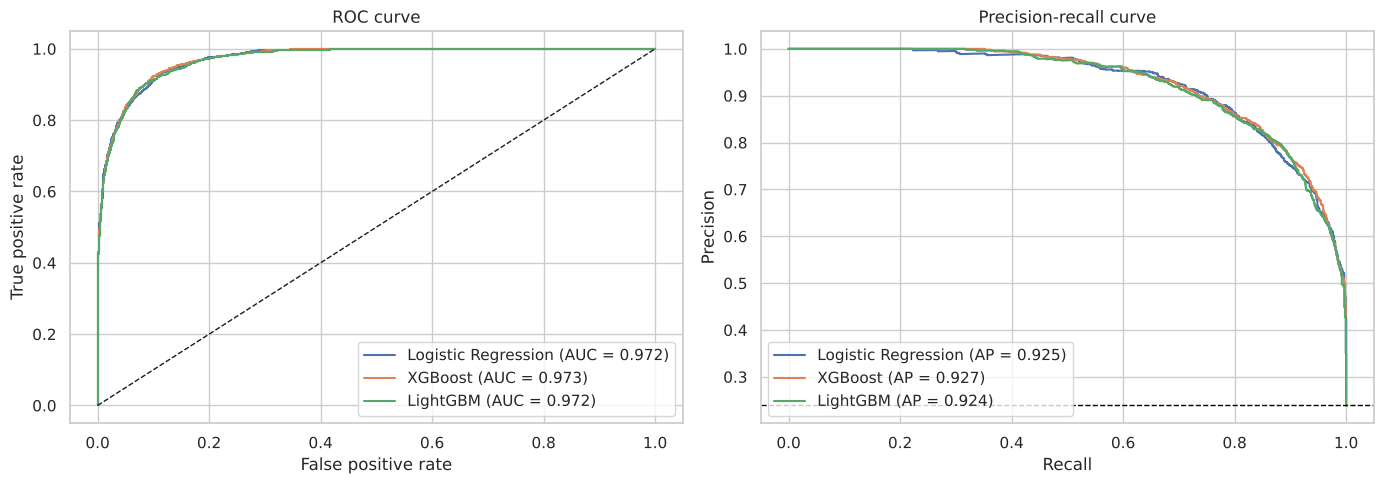

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
axes[1].axhline(y_test.mean(), color="black", ls="--", lw=1)
axes[1].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(loc="lower right" if ax is axes[0] else "lower left")
plt.tight_layout()
plt.show()

In [16]:
best_name = "Logistic Regression"
best_model = models[best_name]
best_proba = probas[best_name]
print(f"Final model: {best_name}\n")
print(classification_report(y_test, (best_proba >= 0.5).astype(int),
                            target_names=["Rejected", "Approved"], digits=3))

Final model: Logistic Regression

              precision    recall  f1-score   support

    Rejected      0.966     0.906     0.935      4566
    Approved      0.751     0.899     0.818      1434

    accuracy                          0.905      6000
   macro avg      0.859     0.903     0.877      6000
weighted avg      0.915     0.905     0.907      6000



The three models are within 0.002 ROC AUC of each other on the test set, so the boosted trees bring no real gain here. **Logistic Regression is chosen as the final model**: it performs as well, and each decision can be explained with its coefficients, which matters for lending decisions. The classification report above uses the default 0.5 threshold.

## 8. What drives the decision?

Permutation importance measures how much the test ROC AUC drops when one column is shuffled. A large drop means the model relies on that column.

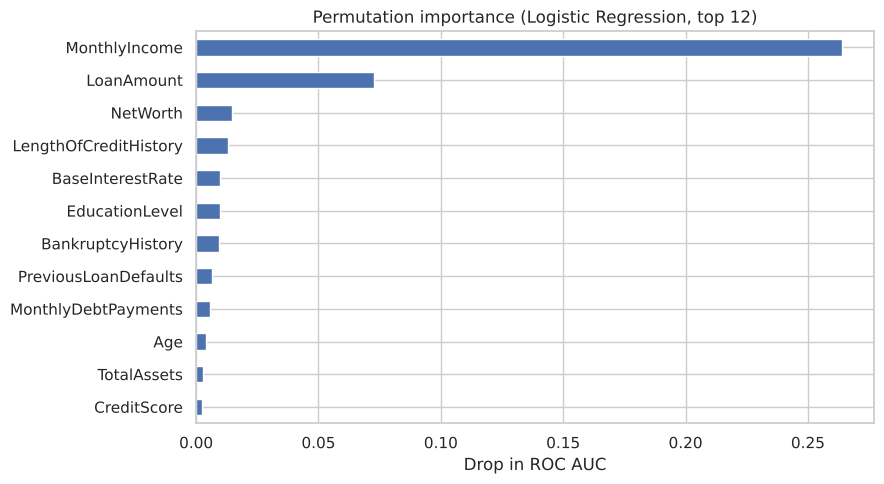

In [17]:
perm = permutation_importance(best_model, X_test[cols], y_test, scoring="roc_auc",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=cols).sort_values(ascending=False)

ax = importance.head(12).sort_values().plot.barh(color="C0", figsize=(9, 5))
ax.set(title=f"Permutation importance ({best_name}, top 12)", xlabel="Drop in ROC AUC")
plt.tight_layout()
plt.show()

The logistic regression coefficients give the direction of each effect (all numeric features are standardised, so their sizes can be compared):

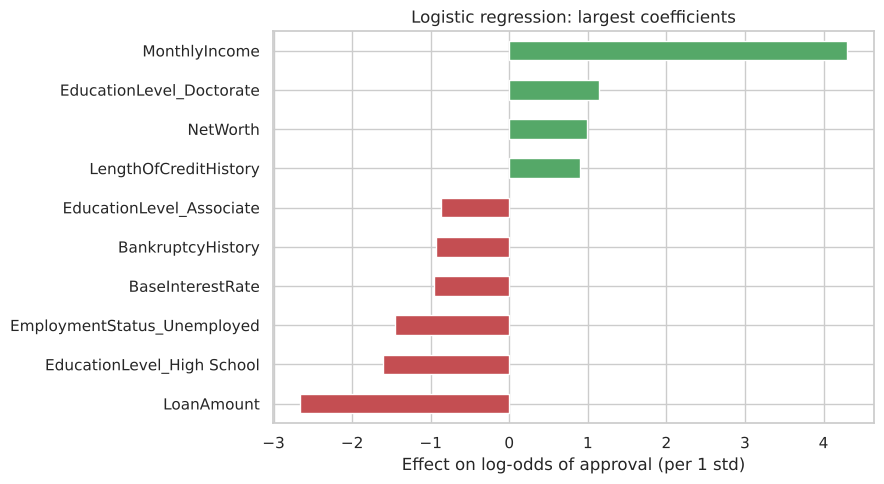

In [18]:
logit = models["Logistic Regression"]
names = logit.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(logit.named_steps["clf"].coef_[0], index=names)
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)

ax = top_coefs.sort_values().plot.barh(color=["C3" if v < 0 else "C2" for v in top_coefs.sort_values()],
                                       figsize=(9, 5))
ax.set(title="Logistic regression: largest coefficients", xlabel="Effect on log-odds of approval (per 1 std)")
plt.tight_layout()
plt.show()

## 9. Choosing the approval threshold

By default a loan is approved when the predicted probability is at least 0.5. The lender can move this threshold: a higher threshold approves fewer loans but makes fewer mistakes among the approved ones.

In [19]:
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = best_proba >= t
    tp = (pred & (y_test == 1)).sum()
    fp = (pred & (y_test == 0)).sum()
    fn = (~pred & (y_test == 1)).sum()
    rows.append({
        "threshold": t,
        "approved by model": int(pred.sum()),
        "wrongly approved": int(fp),
        "wrongly rejected": int(fn),
        "precision": tp / (tp + fp),
        "recall": tp / (tp + fn),
    })
threshold_table = pd.DataFrame(rows).set_index("threshold")
threshold_table.round(3)

,approved by model,wrongly approved,wrongly rejected,precision,recall
threshold,,,,,
0.3,2049,688,73,0.664,0.949
0.4,1851,521,104,0.719,0.927
0.5,1716,427,145,0.751,0.899
0.6,1569,324,189,0.793,0.868
0.7,1428,233,239,0.837,0.833
0.8,1272,153,315,0.880,0.780


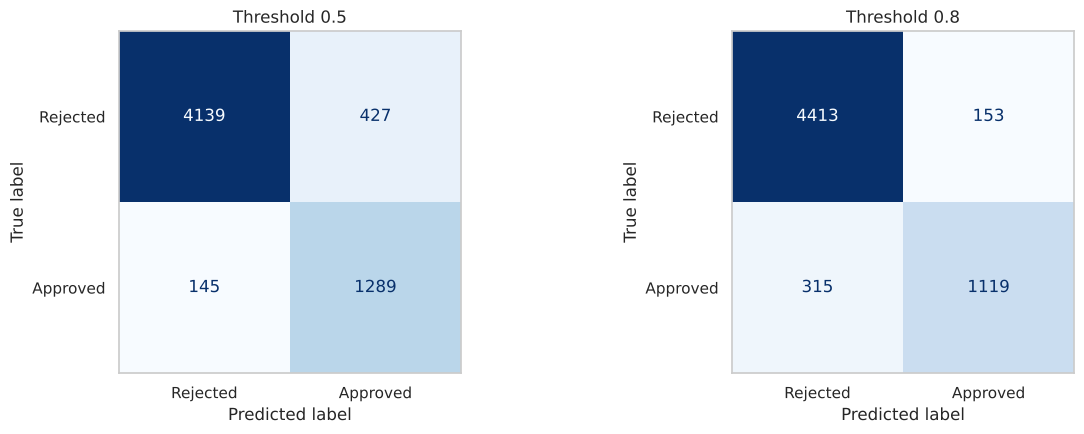

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, t in zip(axes, [0.5, 0.8]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, (best_proba >= t).astype(int), display_labels=["Rejected", "Approved"],
        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Threshold {t}")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 10. Conclusions

- **Approval is highly predictable.** All three models reach a test ROC AUC of about 0.97 using only information from the applicant and the requested loan.
- **A simple model is enough.** Logistic Regression performs as well as XGBoost and LightGBM, and it is easier to explain, so it is the final model.
- **The main drivers** are income, by far, and the loan amount. Net worth, length of credit history, education level and past bankruptcies or defaults come next. Credit score adds little once these are known.
- **Leakage was checked, not assumed away.** `RiskScore` alone reproduces 96.5% of decisions and was removed. `InterestRate` was removed, and so were the two columns calculated from it, which made almost no difference to performance.
- **The threshold is a business choice.** The threshold table shows how many good applicants are rejected for each bad loan avoided. The final threshold should come from the cost of a default compared with the profit of a good loan.

**Limitations and next steps**

- The data is synthetic: approval is generated from a scoring rule, which explains the very high accuracy. Real lending data would be noisier.
- Approval is not the same as repayment. A real credit model should predict default, with approval decisions made from it.
- Next steps: tune hyperparameters, check calibration of the predicted probabilities, add SHAP values to explain individual decisions, and model `RiskScore` as a regression target.